In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import shap

In [ ]:
# Load dataset
train_path = "../Data/cleaned_train_dataset.csv"
train_df = pd.read_csv(train_path)

In [3]:
# Check for duplicates
duplicates = train_df.duplicated(subset=["country_name", "year", "series_name"], keep=False)
duplicates.sum()

80

In [4]:
# Aggregate duplicate values using mean
train_df = train_df.groupby(["country_name", "year", "series_name"], as_index=False).agg({"value": "mean"})

In [5]:
# Convert dataset to wide format
df_wide = train_df.pivot(index=["country_name", "year"], columns="series_name", values="value").reset_index()

In [6]:
# Drop rows with missing target values
target_variable = "Life expectancy at birth, total (years)"
df_wide = df_wide.dropna(subset=[target_variable])

In [9]:
# Define x and y
X = df_wide.drop(columns=["country_name", "year", target_variable])
y = df_wide[target_variable]

In [10]:
# Handle missing values if any by filling with median
X.fillna(X.median(), inplace=True)

In [11]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Train a random forest 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y)

RandomForestRegressor(random_state=42)

In [13]:
# SHAP analysis
explainer = shap.Explainer(rf_model, X_scaled)
shap_values = explainer(X_scaled)

 92%|==================  | 608/660 [00:11<00:00]       

/Users/jen/anaconda3/lib/python3.11/site-packages/shap/plots/_beeswarm.py:950: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  pl.tight_layout()


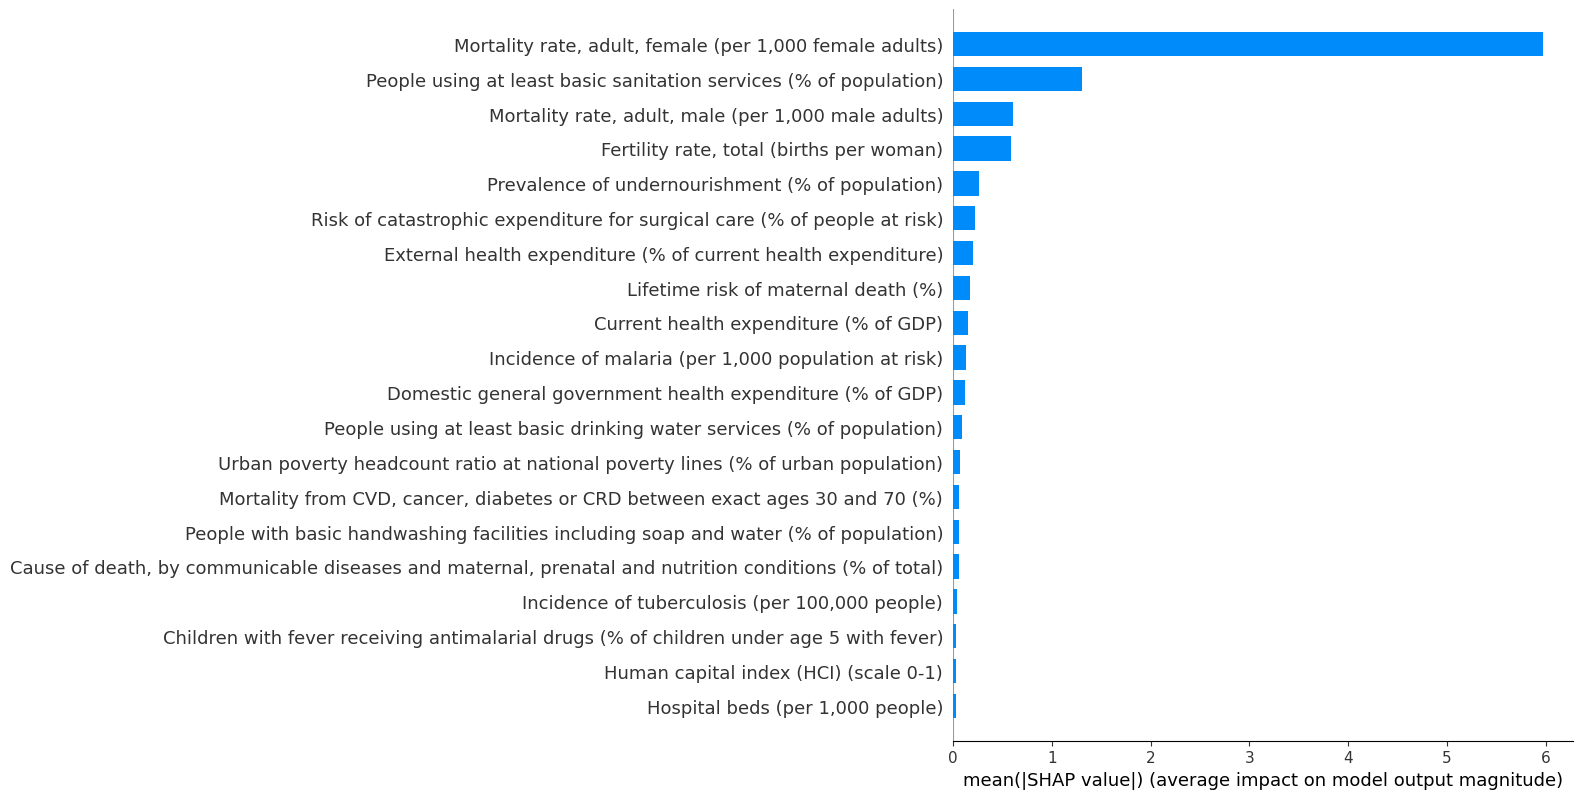

In [14]:
# Visualizing SHAP
shap.summary_plot(shap_values, X, plot_type="bar")

We performed a SHAP feature importance analysis to identify the most influential predictors in our dataset. This helps us understand the contribution of each variable to model predictions and help us in prioritizing features for better accuracy and efficiency.

Key findings
- Adult female mortality rate is the strongest predictor, it suggest a significant relationship with health outcomes.
- Access to basic sanitation services and adult male mortality rate also rank high in importance.
- Risk of catastrophic health expenditure and external health expenditure are among the top financial predictors, which highlights the impact of economic factors on healthcare access and spending.

Based on this plot, we will prioritize important features by keeping the top predictors with the highest SHAP values, as they have the most significant impact on our target variable. To reduce dimensionality, we will consider removing or grouping features with low importance scores, so that only meaningful predictors remain. 

Create feature interactions - we created new variables by combining existing features to capture deeper relationships in the data
- Doctor-to-bed ratio = physicians per 1,000 people / hospital beds per 1,000 people. This measures the availability of physicians relative to hospital beds, helping to indicate healthcare resource allocation.
- Out-of-pocket expenditure burden = out-of-pocket health expenditure / total health expenditure. This represents the share of healthcare spending directly paid by individuals, helping to reveal financial strain.
- Disease burden index = combination of prevalence of undernourishment, mortality rate, and incidence of major diseases. This integrates multiple health-related indicators to assess the overall disease impact in different regions.
- Healthcare expenditure as % of GDP = total health expenditure / GDP per capita. This evaluates a country’s healthcare investment relative to its economic output.

We created these engineered features to help capture complex relationships that single variables might miss.

In [ ]:
# Load the dataset again
train_df = pd.read_csv("../Data/cleaned_train_dataset.csv")

In [20]:
# Remove unnecessary columns
drop_columns = ["Data from database: Health Nutrition and Population Statistics", "Last Updated: 12/16/2024"]
train_df = train_df.drop(columns=drop_columns, errors="ignore")

In [21]:
# Convert to wide format
df_features = train_df.groupby(["country_name", "year", "series_name"], as_index=False)["value"].mean()
# Pivot to wide format
df_wide = df_features.pivot(index=["country_name", "year"], columns="series_name", values="value").reset_index()
df_wide.columns.name = None

In [22]:
# Feature engineering - create new features
df_wide["doctor_bed_ratio"] = df_wide["Physicians (per 1,000 people)"] / df_wide["Hospital beds (per 1,000 people)"]
df_wide["oop_exp_burden"] = df_wide["Out-of-pocket expenditure (% of current health expenditure)"] / df_wide["Current health expenditure (% of GDP)"]

df_wide["disease_burden_index"] = (
    df_wide["Prevalence of undernourishment (% of population)"] +
    df_wide["Mortality rate, adult, male (per 1,000 male adults)"] +
    df_wide["Mortality rate, adult, female (per 1,000 female adults)"] +
    df_wide["Incidence of malaria (per 1,000 population at risk)"]
)

df_wide["health_exp_gdp"] = df_wide["Current health expenditure (% of GDP)"] / df_wide["GNI per capita, Atlas method (current US$)"]

In [23]:
# Handle divisions by zero and infinities
df_wide.replace([np.inf, -np.inf], np.nan, inplace=True)

In [24]:
# Make sure that all columns exist
metadata_columns = ["category", "income_group_numeric", "lag3", "lag5", "rolling3", "rolling5", "growth_rate"]
df_meta = train_df[["country_name", "year"] + metadata_columns].drop_duplicates(subset=["country_name", "year"])

# Merge
df_wide = df_wide.merge(df_meta, on=["country_name", "year"], how="left")

# Remove unnecessary columns from wide dataset again
df_wide = df_wide.drop(columns=drop_columns, errors="ignore")

In [25]:
# Convert to long format
df_long = df_wide.melt(
    id_vars=["country_name", "year", "category", "income_group_numeric", 
             "lag3", "lag5", "rolling3", "rolling5", "growth_rate", 
             "doctor_bed_ratio", "oop_exp_burden", "disease_burden_index", "health_exp_gdp"], 
    var_name="series_name", 
    value_name="value"
)
# Make sure that unnecessary columns are removed from long dataset
df_long = df_long.drop(columns=drop_columns, errors="ignore")

In [31]:
# Re-arrange columns for better readability
column_order = [
    "country_name", "year", "series_name", "value",
    "category", "income_group_numeric", 
    "lag3", "lag5", "rolling3", "rolling5", "growth_rate",
    "doctor_bed_ratio", "oop_exp_burden", "disease_burden_index", "health_exp_gdp"
]
df_long = df_long[column_order]

In [ ]:
# Save the wide-format dataset
df_wide.to_csv("../Data/week5_wide_data.csv", index=False)
# Save the long-format dataset
df_long.to_csv("../Data/week5_long_data.csv", index=False)

In [30]:
# Check for data imbalance
# Check count of records per country
country_counts = train_df["country_name"].value_counts()
# Check count of records per income group
income_group_counts = train_df["income_group_numeric"].value_counts()
# Check count of records per year
year_counts = train_df["year"].value_counts().sort_index()

# Eesults
print("Records per country:\n", country_counts.head(10))
print("\n Records per income group:\n", income_group_counts)
print("\n Records per year:\n", year_counts)

Records per country:
 country_name
Afghanistan       1100
Mexico            1000
United States     1000
United Kingdom    1000
Uganda            1000
Switzerland       1000
Sweden            1000
Sudan             1000
South Africa      1000
Rwanda            1000
Name: count, dtype: int64

 Records per income group:
 income_group_numeric
1    11100
2    11000
3    11000
Name: count, dtype: int64

 Records per year:
 year
2002    1655
2003    1655
2004    1655
2005    1655
2006    1655
2007    1655
2008    1655
2009    1655
2010    1655
2011    1655
2012    1655
2013    1655
2014    1655
2015    1655
2016    1655
2017    1655
2018    1655
2019    1655
2020    1655
2021    1655
Name: count, dtype: int64


To ensure our dataset is well-represented, we analyzed the distribution of records across countries, income groups, and years. We want to identify any significant imbalances that might require synthetic data. Our results showed that all countries had similar record counts, income groups were evenly distributed, and every year from 2002 to 2021 had a consistent number of records. Given this, we determined that data augmentation was unnecessary. 